In [ ]:
import pandas as pd

# Data Loading

In [ ]:
df = pd.read_csv('NetflixOriginals.csv', encoding='latin-1')
df

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi
...,...,...,...,...,...,...
579,Taylor Swift: Reputation Stadium Tour,Concert Film,"December 31, 2018",125,8.4,English
580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,"October 9, 2015",91,8.4,English/Ukranian/Russian
581,Springsteen on Broadway,One-man show,"December 16, 2018",153,8.5,English
582,Emicida: AmarElo - It's All For Yesterday,Documentary,"December 8, 2020",89,8.6,Portuguese


In [ ]:
df.isnull().sum()

,0
Title,0
Genre,0
Premiere,0
Runtime,0
IMDB Score,0
Language,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    object 
 1   Genre       584 non-null    object 
 2   Premiere    584 non-null    object 
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 27.5+ KB


# EDA (Exploratory Data Analysis)


In [ ]:
# Cek kualitas data
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
# Statistik deskriptif (memahami data angka)
df.describe()

,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [ ]:
# Melihat distribusi data kategori
df['Genre'].value_counts()
df['Language'].value_counts()

,count
Language,
English,401
Hindi,33
Spanish,31
French,20
Italian,14
Portuguese,12
Indonesian,9
Korean,6
Japanese,6


In [ ]:
# Preprocessing sederhana
df['Premiere'] = pd.to_datetime(df['Premiere'], format='mixed')
df['Year'] = df['Premiere'].dt.year

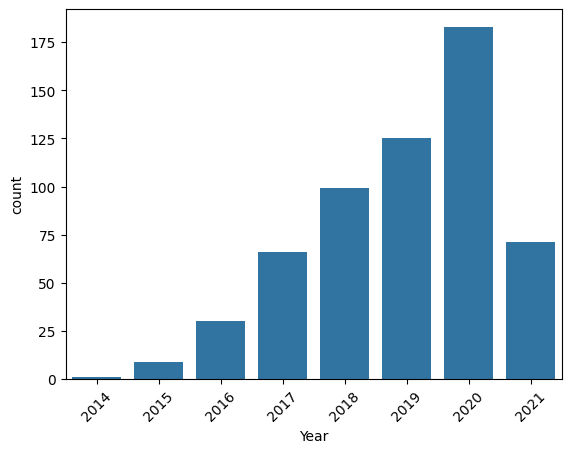

In [ ]:
# Visualisasi Film per tahun
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Year', data=df)
plt.xticks(rotation=45)
plt.show()

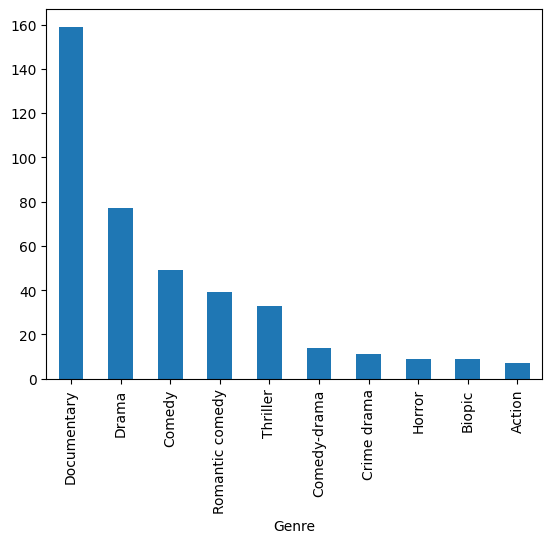

In [ ]:
# Visualisasi Genre Terbanyak
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.show()

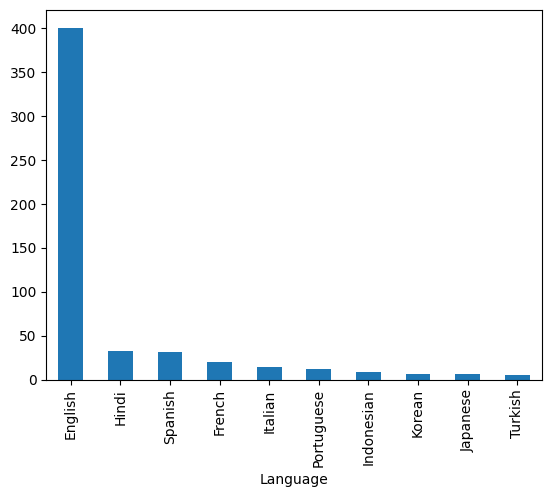

In [ ]:
# Visualisasi bahasa terbanyak
df['Language'].value_counts().head(10).plot(kind='bar')
plt.show()

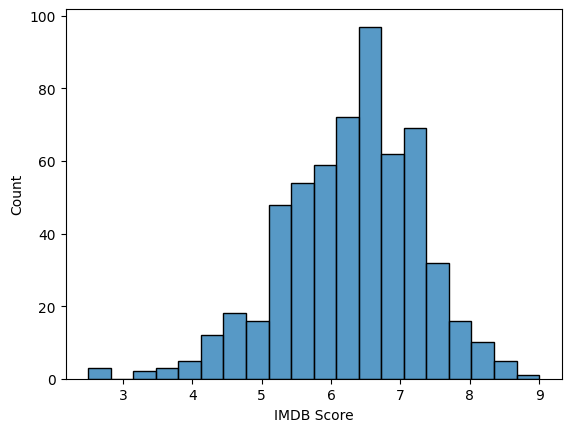

In [ ]:
# Visualisasi distribusi rating
sns.histplot(df['IMDB Score'], bins=20)
plt.show()

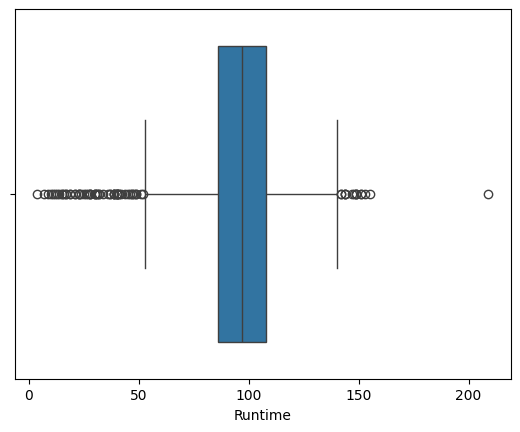

In [ ]:
# Visualisasi dustribusi durasi
sns.boxplot(x=df['Runtime'])
plt.show()

In [ ]:
# Analisis sederhana film terbaik & terburuk
df.sort_values(by='IMDB Score', ascending=False).head(5)
df.sort_values(by='IMDB Score').head(5)

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish,2020
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian,2019
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi,2020


In [ ]:
# Rata-rata rating per genre
df.groupby('Genre')['IMDB Score'].mean().sort_values(ascending=False)

,IMDB Score
Genre,
Animation/Christmas/Comedy/Adventure,8.200000
Musical / Short,7.700000
Concert Film,7.633333
Anthology/Dark comedy,7.600000
Animation / Science Fiction,7.500000
...,...
Superhero-Comedy,4.400000
Horror anthology,4.300000
Political thriller,4.300000


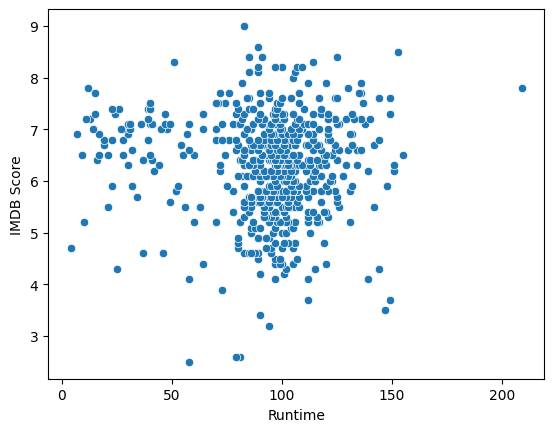

In [ ]:
# Hubungan antar data
sns.scatterplot(x='Runtime', y='IMDB Score', data=df)
plt.show()